# Generative Adversarial Networks (GANs)

Las redes generativas adversariales son modelos generativos enfocados en la generación de imágenes a partir de redes adeversarias; es decir, integran dos redes que "compiten": una que genera imágenes de manera "falsa" y otra que debe distinguir entre una imagen real y una generada por la otra red. De esta forma, el aprendizaje.

<img src="nn3.png" alt="gan" width="400"/>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from tqdm import tqdm

Para iniciar con la construcción de la red GAN, seleccionamos el tamaño de la imagen y del espacio latente.

<b>Espacio latente</b>: En un modelo generativo, el espacio latente se refiere a un espacio, generalmente $\mathbb{R}^n$, que "codifica" la información de un conjunto de datos para que pueda ser decodificada. 

En el caso de la GAN, el espacio latente es un espacio vectorial que busca codificar información sobre las imágenes. Este espacio latente es tomado por el generador para obtener una imágen sintética.

In [2]:
batch_size = 100
image_size = 784
latent_dim = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Elementos de la GAN

La GAN consta de dos redes: la red generadora y la red discriminadora.

<b>Generador</b>: El generador es una red que toma un vector $z$ del espacio latente y genera una imagen o un elemento objetivo $\hat{\mathbf{x}}$ con base a la información codificada en el vector $z$. Se puede entender como una red (feedforward):
$$\hat{\mathbf{x}} = G(z) = f(Wh(z) + b)$$

<b>Discriminador</b>: El discriminador es una red que, dada una imagen (o algún otro elemento) de entrada, determina la probabilidad de que dicha entrada sea auténtica o generada sintéticamente. Es decir:
$$p(R=r|\mathbf{x}) = D(\mathbf{x}) = \sigma(Wh(\mathbf{x}+b)$$
Donde $R \sim Ber(p)$ es una variable binaria que determina la probabilidad de que la entrada sea real.

En este caso, el generador se compone de varias capas densas y una salida sigmoide (puesto que las salidas de los datos están en el intervalo $[0-1]$).

Por su parte, el discriminador se compone de capas convolucionales que procesarán la imagen de entrada, sea real o del generador.

In [3]:
class Generator(nn.Module):
    def __init__(self, latent_dim=64, hidden_dim=128, p=0.3):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(p),
            nn.Linear(hidden_dim, 2*hidden_dim),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(2*hidden_dim),
            nn.Dropout(p),
            nn.Linear(2*hidden_dim, image_size),
            nn.Sigmoid()
        )

    def forward(self, z):
        x = self.net(z)
        return x.view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self, p=0.3):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),  # 28x28 -> 14x14
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(p),
            nn.Conv2d(32, 64, 4, 2, 1), # 14x14 -> 7x7
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(p),
            nn.Flatten(),
            nn.Linear(64* 7*7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

## Datos reales y sintéticos

Los datos de imágenes vienen del dataset MNIST y se trata de digitos escritos a mano. Son imágenes de tamaño $28 \times 28$ con un sólo canal. Por lo que pueden visualizarse en escala de grises.

In [4]:
#Cargamos datos de MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
])
train_dataset = datasets.MNIST(root='~/.pytorch/MNIST_data/', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

El espacio latente es un espacio vectorial $\mathbb{R}^n$. Cada vector $\mathbf{z}$ en el espacio latente puede ser un vector aleatorio (ruido). En este caso, le indicamos una señal de entrada a la que se le puede agregar ruido. De esta forma, la generación estará guiada por los digitos que se pueden presentar; al mismo tiempo, la presencia de rudio puede hacer que se generen datos en regiones cercanas a los digitos en el espacio altente.

In [5]:
def generate_latent(y, batch_size, latent_dim=64,num_classes=10, device='cpu', gamma=0.01):
    z_noise = torch.randn(batch_size, latent_dim, device=device)
    y_onehot = torch.zeros(batch_size, num_classes, device=device)
    y_onehot.scatter_(1, y.view(-1, 1), 1)

    if latent_dim < num_classes:
        raise ValueError("El valor del numero no es adecuado")
    
    z = torch.cat([y_onehot, torch.zeros(batch_size, latent_dim, device=device)[:, num_classes:]], dim=1)
    z = (1-gamma)*z + gamma*z_noise
    
    return z

#generate_latent(torch.tensor([0]),1)

Definimos una función que permitirá visualizar las imágenes generadas por el generador de la GAN. En esta función podemos agregar cierta cantidad de ruido en la señal del espacio altente.

In [6]:
def visualize(num, Gen, size=2, gamma=0.4):
     with torch.no_grad():
        test_z = generate_latent(torch.tensor([num]), 1, device=device, gamma=gamma) #torch.randn(1, latent_dim, device=device)
        gen_img = Gen(test_z).cpu().squeeze().numpy()
        plt.figure(figsize=(size,size))
        plt.imshow(gen_img, cmap="Greys")
        plt.axis("off")
        plt.show()

## Entrenamiento

En primer lugar, creamos los modelos de generador y discriminador. Los llevamos a <tt>device</tt> para poder manejarlos más eficientemente cuando contemos con un GPU. Podemos visualizar que, en principio, las imágenes generadas responden sólo a ruido.

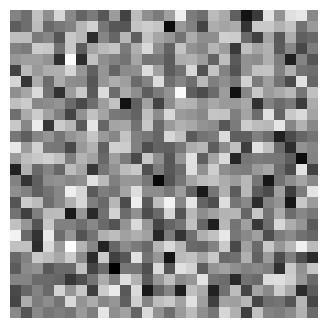

In [7]:
G = Generator(latent_dim).to(device)
D = Discriminator().to(device)

G.eval()
visualize(0, G, size=4)

La función típica de entrenamiento de una GAN está dada por un minimax sobre el generador y el discriminador. La podemos definir como:

$$\min_G \max_D V(G,D) = \min_G \max_D \mathbb{E}\Big[\ln D(\mathbf{x})\Big] + \mathbb{E}\Big[\ln\big(1-D(G(\mathbf{z}))\big)\Big]$$

Ya que trabajamos con descenso por gradiente, tenemos que minimizar la función. Para simplificarla, usaremos la entropia cruzada binaria (BCE), la cuál podremos obtener al cambiar el signo como:

$$\max_G \min_D -V(G,D) = \max_G \min_D -\mathbb{E}\Big[\ln D(\mathbf{x})\Big] - \mathbb{E}\Big[\ln\big(1-D(G(\mathbf{z}))\big)\Big]$$

En este caso, optimizaremos para el discriminador observando que:

$$\min_D -V(G,D) = \min_D -\Big(\mathbb{E}\Big[\ln D(\mathbf{x})\Big] + \mathbb{E}\Big[\ln\big(1-D(G(\mathbf{z}))\big)\Big] \Big)$$

Puede aplicarse por una BCE tomando a la imagen original $\mathbf{x}$ como la clase 1, y a la imagen generada $G(\mathbf{z})$ como la clase 0.

Por su parte, para maximizar el generador, podemos ignorar la parte izquierda de la suma, pues ésta no depende de G, obteniendo:

$$\max_G V(G,D) = \max_G -\mathbb{E}\Big[\ln\big(1-D(G(\mathbf{z}))\big)\Big]$$

Ya que la salida de $D$ es una probabilidad determinada por la función softmax, y sabiendo que $\min p = \max 1-p$ para una probabilidad $p$, simplemente nos queda:

$$\min_G -\mathbb{E}\Big[\ln\big(D(G(\mathbf{z}))\big)\Big]$$

Tanto la función de optimización de $D$ como de $G$ se pueden implementar usando entropía cruzada binaria (BCE), sólo con cuidado de determinar adecuadamente las clases.

In [8]:
#Criterios para entrenamiento
criterion = nn.BCELoss()

G_opt = optim.Adam(G.parameters(), lr=0.001)
D_opt = optim.Adam(D.parameters(), lr=0.001)

In [25]:
#Entrenamiento
G.train()
D.train()
epochs = 10
for epoch in range(epochs):
    for x, y in tqdm(train_loader):
        x = x.to(device)
        y = y.to(device)
        bs = x.size(0)
        
        #Genera supervisión para BCE
        real_label = torch.ones(bs, 1, device=device)
        gen_label = torch.zeros(bs, 1, device=device)
        
        #Discriminador
        z = generate_latent(y, bs, device=device,gamma=0.1) #torch.randn(bs, latent_dim, device=device)
        real_pred, gen_pred = D(x), D(G(z).detach())
        
        D_opt.zero_grad()
        D_loss_real = criterion(real_pred, real_label)
        D_loss_gen = criterion(gen_pred, gen_label)
        D_loss = D_loss_real + D_loss_gen
        D_loss.backward()
        D_opt.step()

        #Generador
        z = generate_latent(y, bs, device=device,gamma=0.1) #torch.randn(bs, latent_dim, device=device)
        output = D(G(z))
        
        G_opt.zero_grad()
        G_loss = criterion(output, real_label)
        G_loss.backward()
        G_opt.step()
    
    print(f"Epoch [{epoch}/{epochs}] D_loss: {D_loss.item():.4f} G_loss: {G_loss.item():.4f}")
    torch.save(G.state_dict(), f'weights/G{epoch+20}.model')
    torch.save(D.state_dict(), f'weights/D{epoch+20}.model')
    
    #visualize(5, G, gamma=0)

100%|█████████████████████████████████████████| 600/600 [01:17<00:00,  7.76it/s]


Epoch [0/10] D_loss: 0.1460 G_loss: 5.6458


100%|█████████████████████████████████████████| 600/600 [01:09<00:00,  8.69it/s]


Epoch [1/10] D_loss: 0.2951 G_loss: 5.1766


100%|█████████████████████████████████████████| 600/600 [01:16<00:00,  7.81it/s]


...

Epoch [7/10] D_loss: 0.8725 G_loss: 1.7366


100%|█████████████████████████████████████████| 600/600 [01:15<00:00,  7.94it/s]


Epoch [8/10] D_loss: 0.5750 G_loss: 1.9764


100%|█████████████████████████████████████████| 600/600 [01:11<00:00,  8.40it/s]

Epoch [9/10] D_loss: 0.6831 G_loss: 2.6049


## Evaluación

En este caso, tenemos que observar que para fines generativos, basta el generador. Podemos ver qué tipo de imágenes está generando. En este caso, las imágenes deben ser digitos que respondan a cierto estímulo de entrada en el espaico latente.

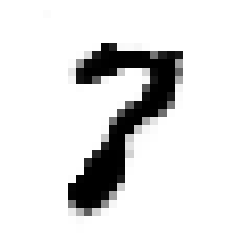

In [10]:
G = Generator(latent_dim)
#visualize(0, G, size=1)
G.load_state_dict(torch.load('weights/G29.model', weights_only=True, map_location='cpu'))
#D.load_state_dict(torch.load('Da.model', map_location='cpu'))

G.eval()
visualize(7, G, size=3, gamma=0)

Recuérdese que el hiperparámetro $\gamma$ introduce ruido en el espacio latente, por lo que si agremamos cierto ruido, la generación puede verse afectada, permitiendo que se generen imágenes de una forma más arbitraria.

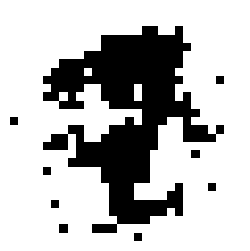

In [15]:
visualize(7, G, size=3, gamma=0.5)